# Travel Expense Analytics & Budget Optimization

### 1. Project Overview

This project analyzes government travel expense data to identify spending patterns, high-cost transactions, data quality issues, and budget optimization opportunities.

### Objectives

- Analyze travel expense trends over time
- Identify major expense categories
- Analyze spending by department and destination
- Detect missing values, negative values, outliers, and anomalies
- Perform exploratory data analysis using Python
- Develop scenario-based budget optimization recommendations

### Tools & Technologies

Python | Pandas | NumPy | Matplotlib | Seaborn

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

In [2]:
# Load the cleaned dataset

file_path = r"C:\Users\kirti\Downloads\Travel_Expense_Cleaned - Cleaned_Data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 152900
Columns: 31


In [3]:
# Display first 5 records

df.head()

,ref_number,disclosure_group,title_en,title_fr,name,purpose_en,purpose_fr,start_date,end_date,destination_en,destination_fr,destination_2_en,destination_2_fr,destination_other_en,destination_other_fr,airfare,other_transport,lodging,meals,other_expenses,total,additional_comments_en,additional_comments_fr,owner_org,owner_org_title,Travel_Days,Calculated_Total,Total_Difference,Duplicate_Flag,Data_Quality_Status,Total_Check
0,T-20120-P11-001,SLE,Chief Executive Officer,Président directeur-général,Philip Rizcallah,To attend meeting with Saskatchewan Provincial...,Pour assister à une réunion avec le gouverneme...,2020-02-03,2020-02-04,"Regina, Saskatchewan, Canada","Regina, Saskatchewan, Canada",NaN,NaN,NaN,NaN,646.17,117.26,157.78,197.25,0.0,1118.46,NaN,NaN,casdo-ocena,Accessibility Standards Canada | Normes d’acce...,2.0,1118.46,0.0,False,OK,OK
1,T-2020-P11-0001,SLE,Chair,Président,"Bérubé, Paul-Claude",Board members meeting,Réunion du conseil,2020-02-09,2020-02-13,"Vancouver, British Columbia, Canada","Vancouver, Colombie-Britannique",NaN,NaN,NaN,NaN,1104.27,189.72,841.31,461.84,NaN,2597.14,NaN,NaN,casdo-ocena,Accessibility Standards Canada | Normes d’acce...,5.0,2597.14,0.0,False,OK,OK
2,T-2020-P11-0002,SLE,Vice Chair,vice-présidente,"Reid, Mary",Board members meeting,Réunion du conseil,2020-02-09,2020-02-14,"Vancouver, British Columbia, Canada","Vancouver, Colombie-Britannique",NaN,NaN,NaN,NaN,2511.31,132.48,785.65,591.00,108.3,4128.74,NaN,NaN,casdo-ocena,Accessibility Standards Canada | Normes d’acce...,6.0,4128.74,0.0,False,OK,OK
3,T-2020-P11-0003,SLE,Board Of Directors,Membre du conseil de direction,"McLaughlin, Joseph",Board members meeting,Réunion du conseil,2020-02-09,2020-02-12,"Vancouver, British Columbia, Canada","Vancouver, Colombie-Britannique",NaN,NaN,NaN,NaN,NaN,58.32,630.99,264.60,123.0,1076.91,NaN,NaN,casdo-ocena,Accessibility Standards Canada | Normes d’acce...,4.0,1076.91,0.0,False,OK,OK
4,T-2020-P11-0004,SLE,Board Of Directors,Membre du conseil de direction,"Haan, Maureen",Board members meeting,Réunion du conseil,2020-02-09,2020-02-12,"Vancouver, British Columbia, Canada","Vancouver, Colombie-Britannique",NaN,NaN,NaN,NaN,880.99,192.76,630.99,332.45,NaN,2037.19,NaN,NaN,casdo-ocena,Accessibility Standards Canada | Normes d’acce...,4.0,2037.19,0.0,False,OK,OK


## 4. Dataset Overview

This section provides an overview of the dataset, including its structure, columns, data types, missing values, and basic statistical information.

In [4]:
# Dataset information

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (152900, 31)

Column Names:
['ref_number', 'disclosure_group', 'title_en', 'title_fr', 'name', 'purpose_en', 'purpose_fr', 'start_date', 'end_date', 'destination_en', 'destination_fr', 'destination_2_en', 'destination_2_fr', 'destination_other_en', 'destination_other_fr', 'airfare', 'other_transport', 'lodging', 'meals', 'other_expenses', 'total', 'additional_comments_en', 'additional_comments_fr', 'owner_org', 'owner_org_title', 'Travel_Days', 'Calculated_Total', 'Total_Difference', 'Duplicate_Flag', 'Data_Quality_Status', 'Total_Check']

Data Types:
ref_number                 object
disclosure_group           object
title_en                   object
title_fr                   object
name                       object
purpose_en                 object
purpose_fr                 object
start_date                 object
end_date                   object
destination_en             object
destination_fr             object
destination_2_en           object
destination_2_fr   

In [5]:
# Basic statistical summary

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ref_number,152898,93813,T-2025-P12-0001,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disclosure_group,131475,4,SLE,82812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title_en,152192,6511,Chief of Staff,3971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title_fr,152162,8362,Président,3308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,152352,9363,Carol Sheedy,459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose_en,152882,86720,Various meetings,1318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose_fr,152787,88619,Activités opérationnelles,1250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_date,152900,7893,2024-10-15,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_date,152092,7903,2024-09-27,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_en,152231,22208,"Ottawa, Ontario, Canada",11573,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Missing values summary

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': (missing_values / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary['Missing Values'] > 0
].sort_values('Missing Values', ascending=False)

missing_summary

,Missing Values,Missing Percentage
destination_other_en,152203,99.54
destination_other_fr,152203,99.54
destination_2_en,150214,98.24
destination_2_fr,150214,98.24
additional_comments_fr,129768,84.87
additional_comments_en,128439,84.00
disclosure_group,21425,14.01
other_expenses,14056,9.19
airfare,6120,4.00
other_transport,3916,2.56


## 5. Data Cleaning

The dataset is cleaned by standardizing text fields, converting date columns into datetime format, and ensuring expense-related columns are stored as numeric values.

In [7]:
# Create a copy for cleaning
cleaned_df = df.copy()

# Remove leading and trailing spaces from text columns
text_columns = cleaned_df.select_dtypes(include='object').columns

for col in text_columns:
    cleaned_df[col] = cleaned_df[col].str.strip()

print("Text fields cleaned successfully.")

Text fields cleaned successfully.


In [8]:
# Convert date columns to datetime

cleaned_df['start_date'] = pd.to_datetime(
    cleaned_df['start_date'], errors='coerce'
)

cleaned_df['end_date'] = pd.to_datetime(
    cleaned_df['end_date'], errors='coerce'
)

print("Date columns converted successfully.")

Date columns converted successfully.


In [9]:
# Convert expense columns to numeric

expense_columns = [
    'airfare',
    'other_transport',
    'lodging',
    'meals',
    'other_expenses',
    'total'
]

for col in expense_columns:
    cleaned_df[col] = pd.to_numeric(
        cleaned_df[col], errors='coerce'
    )

print("Expense columns converted to numeric successfully.")

Expense columns converted to numeric successfully.


In [10]:
# Verify cleaned data types

cleaned_df[expense_columns].dtypes

airfare            float64
other_transport    float64
lodging            float64
meals              float64
other_expenses     float64
total              float64
dtype: object

In [11]:
# Calculate travel duration

cleaned_df['Travel_Days'] = np.where(
    cleaned_df['start_date'].notna() & cleaned_df['end_date'].notna(),
    (cleaned_df['end_date'] - cleaned_df['start_date']).dt.days + 1,
    np.nan
)

# Calculate total from individual expense components

cleaned_df['Calculated_Total'] = cleaned_df[
    ['airfare', 'other_transport', 'lodging', 'meals', 'other_expenses']
].sum(axis=1, min_count=1)

print("Derived columns created successfully.")

Derived columns created successfully.


In [12]:
# Display derived columns

cleaned_df[
    ['start_date', 'end_date', 'Travel_Days',
     'total', 'Calculated_Total']
].head(10)

,start_date,end_date,Travel_Days,total,Calculated_Total
0,2020-02-03,2020-02-04,2.0,1118.46,1118.46
1,2020-02-09,2020-02-13,5.0,2597.14,2597.14
2,2020-02-09,2020-02-14,6.0,4128.74,4128.74
3,2020-02-09,2020-02-12,4.0,1076.91,1076.91
4,2020-02-09,2020-02-12,4.0,2037.19,2037.19
5,2020-02-09,2020-02-12,4.0,2036.57,2036.57
6,2020-02-09,2020-02-12,4.0,1953.50,1953.50
7,2020-02-09,2020-02-12,4.0,1754.78,1754.78
8,2020-02-09,2020-02-12,4.0,2037.57,2037.57
9,2020-02-09,2020-02-14,6.0,3530.84,3530.84


In [13]:
# Calculate difference between reported total and calculated total

cleaned_df['Total_Difference'] = (
    cleaned_df['total'] - cleaned_df['Calculated_Total']
).round(2)

print("Total difference calculated successfully.")

Total difference calculated successfully.


In [14]:
# Create data quality status

cleaned_df['Data_Quality_Status'] = np.select(
    [
        cleaned_df['total'].isna(),
        cleaned_df['Total_Difference'].abs() <= 0.01
    ],
    [
        'MISSING_TOTAL',
        'OK'
    ],
    default='CHECK'
)

cleaned_df['Data_Quality_Status'].value_counts()

Data_Quality_Status
OK               149649
CHECK              3062
MISSING_TOTAL       189
Name: count, dtype: int64

In [15]:
# Show records requiring data quality review

quality_check = cleaned_df[
    cleaned_df['Data_Quality_Status'] != 'OK'
]

print("Records requiring review:", len(quality_check))

quality_check[
    ['ref_number', 'total', 'Calculated_Total',
     'Total_Difference', 'Data_Quality_Status']
].head(10)

Records requiring review: 3251


,ref_number,total,Calculated_Total,Total_Difference,Data_Quality_Status
152,T-2026-P11-00030,176468.00,1764.68,174703.32,CHECK
1161,T-2018-Q3-00063,2337.34,2337.84,-0.50,CHECK
1218,T-2018-Q4-00057,579.97,579.57,0.40,CHECK
1280,T-2026-P04-00064,113947.00,1139.47,112807.53,CHECK
5976,T-2025-P7-0035,12204.18,0.00,12204.18,CHECK
6008,T-2018-Q1-00052,629.00,629.09,-0.09,CHECK
6013,T-2018-Q2-00010,1637.33,1637.44,-0.11,CHECK
6018,T-2018-Q2-00014,1004.54,1004.52,0.02,CHECK
6077,T-2026-P11-00039,21810.00,14961.00,6849.00,CHECK
6117,T-2017-Q4-00014,938.00,938.70,-0.70,CHECK


## 6. Data Quality Analysis

This section evaluates the dataset for missing values, negative expense values, and duplicate records to identify potential data quality issues before analysis.

In [16]:
# Analyze missing values

missing_values = cleaned_df.isnull().sum()

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': (
        missing_values / len(cleaned_df) * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary['Missing Values'] > 0
].sort_values('Missing Values', ascending=False)

missing_summary

,Missing Values,Missing Percentage
destination_other_en,152203,99.54
destination_other_fr,152203,99.54
destination_2_fr,150214,98.24
destination_2_en,150214,98.24
additional_comments_fr,129768,84.87
additional_comments_en,128439,84.00
disclosure_group,21425,14.01
other_expenses,14056,9.19
airfare,6120,4.00
other_transport,3916,2.56


In [17]:
# Check negative values in expense columns

negative_summary = {}

for col in expense_columns:
    negative_summary[col] = (cleaned_df[col] < 0).sum()

negative_summary = pd.DataFrame(
    list(negative_summary.items()),
    columns=['Expense Column', 'Negative Records']
)

negative_summary

,Expense Column,Negative Records
0,airfare,16
1,other_transport,8
2,lodging,0
3,meals,2
4,other_expenses,9
5,total,23


In [18]:
# Check duplicate records

duplicate_count = cleaned_df.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


In [19]:
# Overall data quality summary

data_quality_summary = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Total Columns',
        'Duplicate Records',
        'Missing Total',
        'Missing Start Date',
        'Missing End Date'
    ],
    'Value': [
        len(cleaned_df),
        cleaned_df.shape[1],
        cleaned_df.duplicated().sum(),
        cleaned_df['total'].isna().sum(),
        cleaned_df['start_date'].isna().sum(),
        cleaned_df['end_date'].isna().sum()
    ]
})

data_quality_summary

,Metric,Value
0,Total Records,152900
1,Total Columns,31
2,Duplicate Records,0
3,Missing Total,189
4,Missing Start Date,0
5,Missing End Date,808


## 7. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand travel expense patterns, spending distribution, yearly trends, departmental spending, destination-wise expenses, and expense category contributions.

## 7.1 Expense Distribution

This analysis examines the distribution of total travel expenses to understand the typical spending range and identify extreme expense values.

In [20]:
# Descriptive statistics for total travel expense

expense_stats = cleaned_df['total'].describe()

expense_stats

count    152711.000000
mean       2147.219942
std        3839.770932
min       -4415.390000
25%         506.800000
50%        1256.200000
75%        2426.155000
max      922199.000000
Name: total, dtype: float64

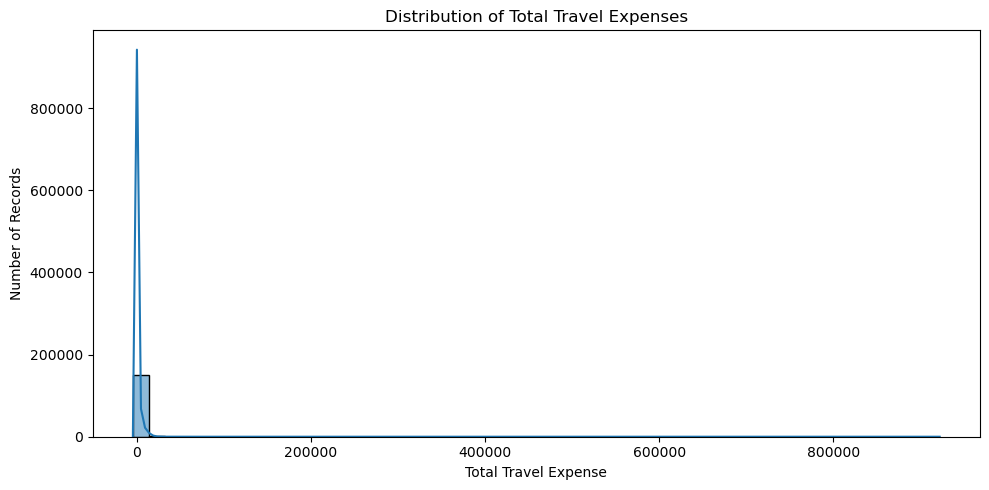

In [21]:
# Distribution of total travel expenses

plt.figure(figsize=(10, 5))

sns.histplot(
    cleaned_df['total'].dropna(),
    bins=50,
    kde=True
)

plt.title('Distribution of Total Travel Expenses')
plt.xlabel('Total Travel Expense')
plt.ylabel('Number of Records')

plt.tight_layout()
plt.show()

### 7.2 Year-wise Travel Expense Analysis
This analysis examines how total travel expenses changed over different years and helps identify major spending trends over time.

In [22]:
# Year-wise travel expense

yearly_expense = (
    cleaned_df[
        cleaned_df['start_date'].notna() &
        cleaned_df['total'].notna()
    ]
    .assign(Year=cleaned_df['start_date'].dt.year)
    .groupby('Year', as_index=False)['total']
    .sum()
    .rename(columns={'total': 'Total_Expense'})
    .sort_values('Year')
)

yearly_expense

,Year,Total_Expense
0,1999,0.00
1,2003,67137.58
2,2004,4540905.82
3,2005,5272765.43
4,2006,4938243.25
5,2007,6196268.95
6,2008,6073208.93
7,2009,7694189.17
8,2010,7828816.55
9,2011,8151691.18


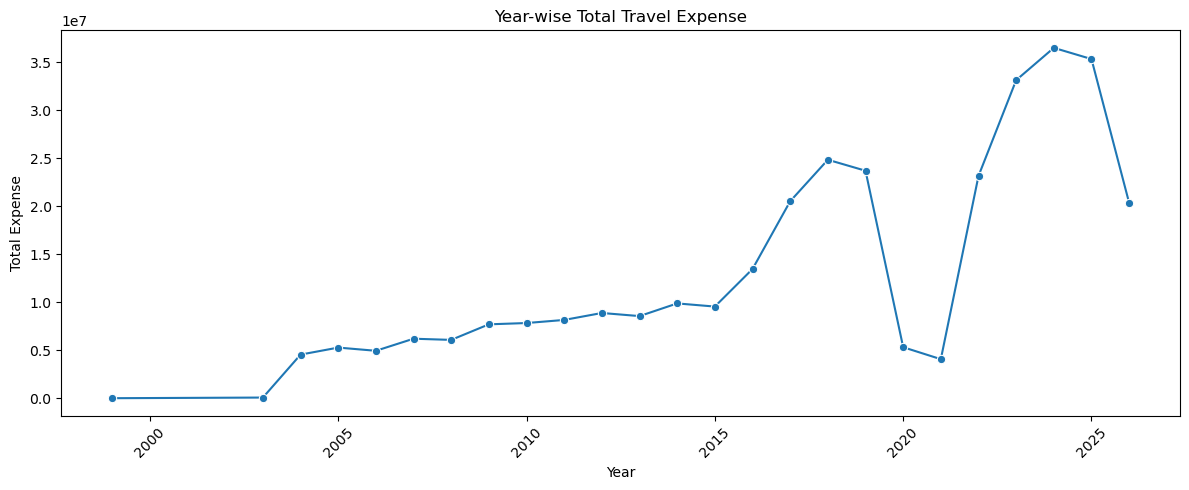

In [23]:
# Visualize year-wise travel expense

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=yearly_expense,
    x='Year',
    y='Total_Expense',
    marker='o'
)

plt.title('Year-wise Total Travel Expense')
plt.xlabel('Year')
plt.ylabel('Total Expense')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
# Highest spending year

highest_spending_year = yearly_expense.loc[
    yearly_expense['Total_Expense'].idxmax()
]

print("Highest Spending Year:", int(highest_spending_year['Year']))
print(
    "Total Expense:",
    round(highest_spending_year['Total_Expense'], 2)
)

Highest Spending Year: 2024
Total Expense: 36490649.42


### 7.3 Department Analysis

This analysis identifies departments with the highest total travel expenses and helps understand department-level spending patterns.

In [25]:
# Department-wise travel expense

department_expense = (
    cleaned_df[
        cleaned_df['owner_org'].notna() &
        cleaned_df['total'].notna()
    ]
    .groupby('owner_org', as_index=False)['total']
    .sum()
    .rename(columns={'total': 'Total_Expense'})
    .sort_values('Total_Expense', ascending=False)
)

department_expense.head(10)

,owner_org,Total_Expense
41,dfatd-maecd,63848705.37
50,esdc-edsc,23424267.77
44,dnd-mdn,22382126.48
56,fin,18165295.08
65,ic,12558238.84
105,pco-bcp,10296318.65
85,nrcan-rncan,8618916.91
33,cra-arc,7277975.67
104,pch,7084876.46
131,tc,6703932.18


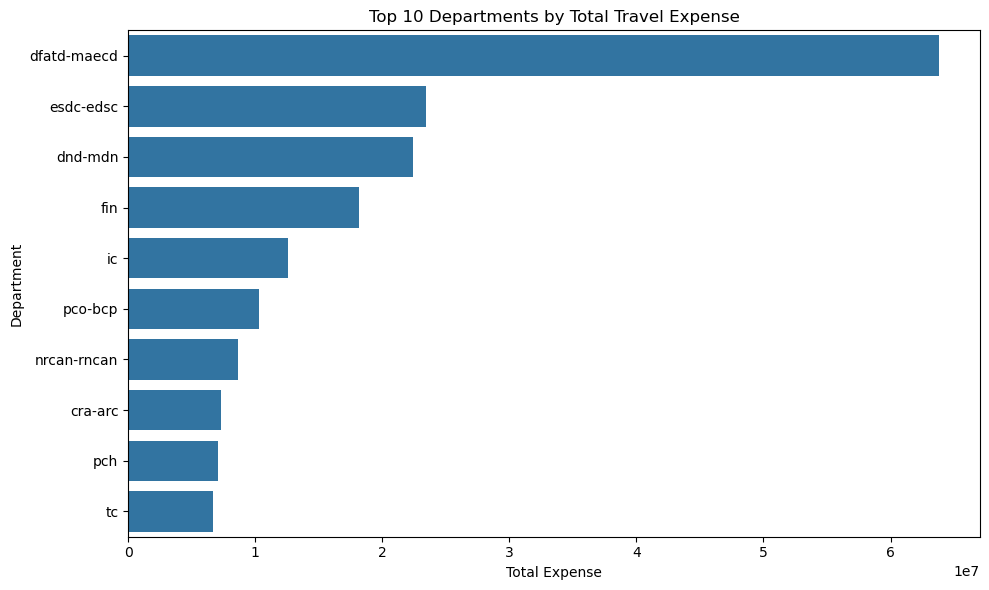

In [26]:
# Top 10 departments by travel expense

top_departments = department_expense.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_departments,
    x='Total_Expense',
    y='owner_org'
)

plt.title('Top 10 Departments by Total Travel Expense')
plt.xlabel('Total Expense')
plt.ylabel('Department')

plt.tight_layout()
plt.show()

In [27]:
    # Highest spending department

top_department = department_expense.iloc[0]

print("Highest Spending Department:", top_department['owner_org'])
print(
    "Total Expense:",
    round(top_department['Total_Expense'], 2)
)

Highest Spending Department: dfatd-maecd
Total Expense: 63848705.37


### 7.4 Destination Analysis

This analysis identifies the destinations associated with the highest total travel expenses and helps understand destination-wise spending patterns.

In [28]:
# Destination-wise travel expense

destination_expense = (
    cleaned_df[
        cleaned_df['destination_en'].notna() &
        cleaned_df['total'].notna()
    ]
    .groupby('destination_en', as_index=False)['total']
    .sum()
    .rename(columns={'total': 'Total_Expense'})
    .sort_values('Total_Expense', ascending=False)
)

destination_expense.head(10)

,destination_en,Total_Expense
18389,"Toronto, Ontario, Canada",13178794.05
12523,"Ottawa, Ontario, Canada",13173293.90
19789,"Vancouver, British Columbia, Canada",6812316.72
13122,"Paris, France",6136294.43
10115,"Montreal, Quebec, Canada",5001970.51
12426,"Ottawa, Ontario",4531891.71
12179,"Ottawa, ON",4267074.73
18060,"Toronto, ON",3927901.40
2348,"Calgary, Alberta, Canada",3506254.53
6199,"Halifax, Nova Scotia, Canada",3328456.59


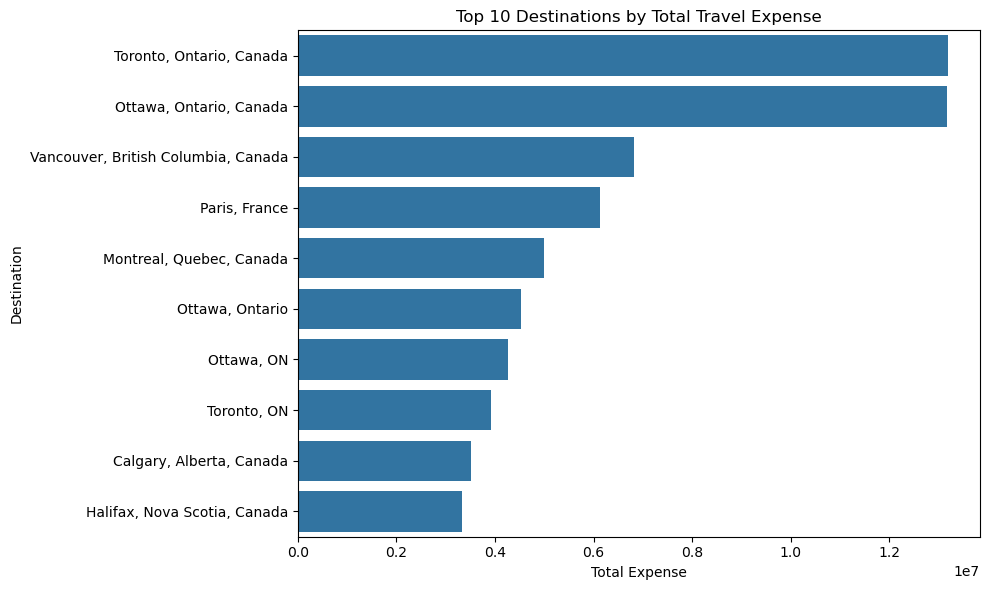

In [29]:
# Top 10 destinations by travel expense

top_destinations = destination_expense.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_destinations,
    x='Total_Expense',
    y='destination_en'
)

plt.title('Top 10 Destinations by Total Travel Expense')
plt.xlabel('Total Expense')
plt.ylabel('Destination')

plt.tight_layout()
plt.show()

In [30]:
# Highest spending destination

top_destination = destination_expense.iloc[0]

print("Highest Spending Destination:", top_destination['destination_en'])
print(
    "Total Expense:",
    round(top_destination['Total_Expense'], 2)
)

Highest Spending Destination: Toronto, Ontario, Canada
Total Expense: 13178794.05


### 7.5 Expense Category Analysis

This analysis compares different travel expense categories to understand their contribution to overall travel spending.

In [31]:
# Calculate total expense by category

category_expense = pd.DataFrame({
    'Expense_Category': [
        'Airfare',
        'Other Transport',
        'Lodging',
        'Meals',
        'Other Expenses'
    ],
    'Total_Expense': [
        cleaned_df['airfare'].sum(),
        cleaned_df['other_transport'].sum(),
        cleaned_df['lodging'].sum(),
        cleaned_df['meals'].sum(),
        cleaned_df['other_expenses'].sum()
    ]
})

category_expense = category_expense.sort_values(
    'Total_Expense',
    ascending=False
)

category_expense

,Expense_Category,Total_Expense
0,Airfare,1.980775e+08
2,Lodging,7.243388e+07
3,Meals,3.567247e+07
1,Other Transport,2.262249e+07
4,Other Expenses,3.417665e+06


In [32]:
# Calculate percentage contribution of each expense category

category_expense['Percentage'] = (
    category_expense['Total_Expense']
    / category_expense['Total_Expense'].sum()
    * 100
).round(2)

category_expense

,Expense_Category,Total_Expense,Percentage
0,Airfare,1.980775e+08,59.62
2,Lodging,7.243388e+07,21.80
3,Meals,3.567247e+07,10.74
1,Other Transport,2.262249e+07,6.81
4,Other Expenses,3.417665e+06,1.03


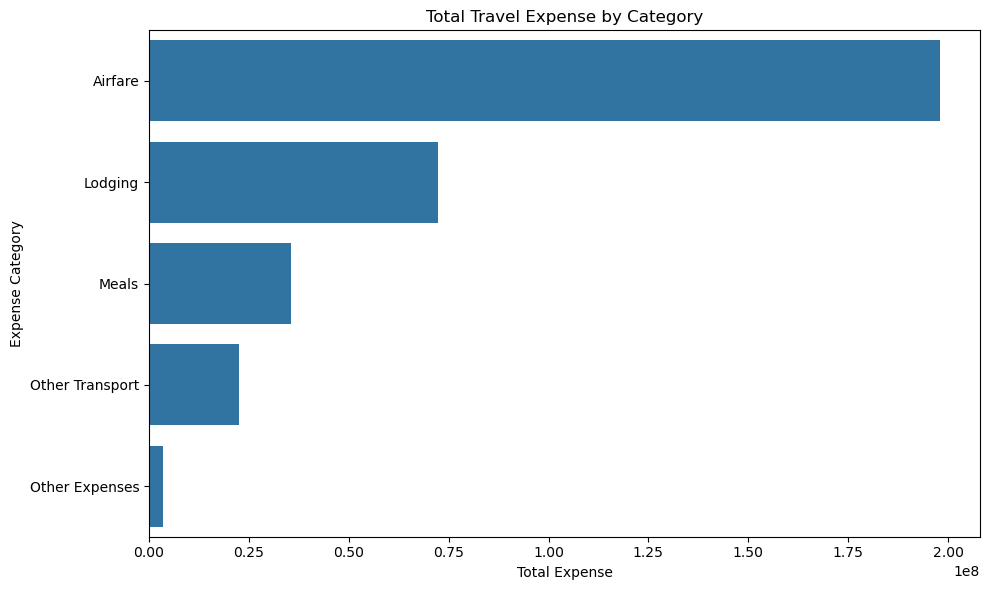

In [33]:
# Visualize expense category contribution

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_expense,
    x='Total_Expense',
    y='Expense_Category'
)

plt.title('Total Travel Expense by Category')
plt.xlabel('Total Expense')
plt.ylabel('Expense Category')

plt.tight_layout()
plt.show()

In [34]:
# Display category percentages

for _, row in category_expense.iterrows():
    print(
        f"{row['Expense_Category']}: "
        f"{row['Percentage']:.2f}%"
    )

Airfare: 59.62%
Lodging: 21.80%
Meals: 10.74%
Other Transport: 6.81%
Other Expenses: 1.03%


## 8. Outlier & Anomaly Analysis

This section identifies unusual travel expense records using statistical methods and examines negative values and potential scale inconsistencies.

### 8.1 IQR-based Outlier Detection

The Interquartile Range (IQR) method is used to identify unusually high or low travel expense values.

In [35]:
# Calculate IQR for total travel expense

expense_data = cleaned_df['total'].dropna()

Q1 = expense_data.quantile(0.25)
Q3 = expense_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = cleaned_df[
    (cleaned_df['total'] < lower_bound) |
    (cleaned_df['total'] > upper_bound)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))
print("Number of Outliers:", len(outliers))

Q1: 506.8
Q3: 2426.15
IQR: 1919.35
Lower Bound: -2372.23
Upper Bound: 5305.19
Number of Outliers: 13491


In [36]:
# Display top extreme expense records

outliers[
    ['ref_number', 'destination_en', 'total']
].sort_values(
    'total',
    ascending=False
).head(10)

,ref_number,destination_en,total
82663,T-2015-P08-00011,"Tokyo, Japan",922199.00
152,T-2026-P11-00030,"Yellowknife, NWT",176468.00
82442,T-2015-P08-00024,"Toronto, Ontario",115005.00
1280,T-2026-P04-00064,"Vancouver, Canada",113947.00
31919,T-2026-P03-0007,"Toronto, Ontario, Canada",64169.76
133589,T-2023-P7-2FBC10AE145E491E8D2B,"Hong Kong, Hong Kong & Shanghai, China",51899.36
31815,T-2025-P03-00041,"Toronto, Ontario, Canada",51393.34
138512,T-2027-P4-0008,"Beijing, China",44518.39
138330,T-2026-P6-0011,"Tel Aviv, Israel",44516.33
44614,T-2027-P1-005,"Mumbai, India",40753.48


### 8.2 Negative Expense Analysis

Negative expense values are reviewed to identify unusual transactions that may require further validation.

In [37]:
# Analyze negative values in expense columns

negative_summary = pd.DataFrame({
    'Expense_Category': expense_columns,
    'Negative_Records': [
        (cleaned_df[col] < 0).sum()
        for col in expense_columns
    ]
})

negative_summary

,Expense_Category,Negative_Records
0,airfare,16
1,other_transport,8
2,lodging,0
3,meals,2
4,other_expenses,9
5,total,23


In [38]:
# Display records containing negative expense values

negative_records = cleaned_df[
    (cleaned_df[expense_columns] < 0).any(axis=1)
]

print("Records with negative expense values:", len(negative_records))

negative_records[
    ['ref_number', 'airfare', 'other_transport',
     'lodging', 'meals', 'other_expenses', 'total']
].head(20)

Records with negative expense values: 34


,ref_number,airfare,other_transport,lodging,meals,other_expenses,total
503,T-2019-P3-0001,0.00,241.96,464.10,153.20,-105.00,754.26
12281,T-2019-P4-0006,1423.40,165.34,495.72,234.40,-28.00,2290.86
13067,T-2021-05-001,-906.60,0.00,0.00,0.00,0.00,-906.60
14617,071066-C,NaN,-2254.70,0.00,0.00,NaN,-2254.70
14621,071066-F,NaN,-2393.83,0.00,0.00,NaN,-2393.83
14626,071066-J,NaN,-1221.54,0.00,0.00,NaN,-1221.54
14636,071066-P,NaN,-1502.07,0.00,0.00,NaN,-1502.07
14669,72488,NaN,-1160.96,0.00,0.00,NaN,-1160.96
29516,T-2020-P8-013,1213.88,112.72,1125.86,517.29,-393.58,2576.17
31759,T-2024-P12-00005,-1125.25,185.45,267.83,0.00,0.00,-671.97


### 8.3 Anomaly / Scale Inconsistency Analysis

This analysis compares the reported total expense with the calculated total to identify records with unusually large differences that may indicate data entry or scale inconsistencies.

In [39]:
# Identify records with significant differences

scale_anomalies = cleaned_df[
    (cleaned_df['total'].notna()) &
    (cleaned_df['Calculated_Total'].notna()) &
    (cleaned_df['Calculated_Total'] > 0) &
    (
        cleaned_df['total'] /
        cleaned_df['Calculated_Total'] > 50
    )
]

print("Potential scale inconsistencies:", len(scale_anomalies))

scale_anomalies[
    [
        'ref_number',
        'destination_en',
        'total',
        'Calculated_Total',
        'Total_Difference'
    ]
].sort_values(
    'total',
    ascending=False
)

Potential scale inconsistencies: 3


,ref_number,destination_en,total,Calculated_Total,Total_Difference
152,T-2026-P11-00030,"Yellowknife, NWT",176468.0,1764.68,174703.32
1280,T-2026-P04-00064,"Vancouver, Canada",113947.0,1139.47,112807.53
11671,T-2025-P10-0003,"Montreal, Quebec, Canada",1331.0,13.31,1317.69


In [40]:
# Review the largest reported-to-calculated total ratios

scale_anomalies = scale_anomalies.copy()

scale_anomalies['Total_Ratio'] = (
    scale_anomalies['total'] /
    scale_anomalies['Calculated_Total']
)

scale_anomalies[
    [
        'ref_number',
        'total',
        'Calculated_Total',
        'Total_Ratio'
    ]
].sort_values(
    'Total_Ratio',
    ascending=False
).head(10)

,ref_number,total,Calculated_Total,Total_Ratio
152,T-2026-P11-00030,176468.0,1764.68,100.0
1280,T-2026-P04-00064,113947.0,1139.47,100.0
11671,T-2025-P10-0003,1331.0,13.31,100.0


## 9. Correlation Analysis

This section examines the relationships between travel duration and expense values to understand whether longer trips are associated with higher travel expenses.

### 9.1 Travel Days vs Total Expense

This analysis evaluates the relationship between travel duration and total travel expense using Pearson correlation.

In [41]:
# Prepare valid data for correlation analysis

correlation_data = cleaned_df[
    (cleaned_df['Travel_Days'] > 0) &
    (cleaned_df['Travel_Days'] <= 365) &
    (cleaned_df['total'].notna())
][['Travel_Days', 'total']].dropna()

correlation_value = correlation_data['Travel_Days'].corr(
    correlation_data['total']
)

print("Travel Days vs Total Expense Correlation:",
      round(correlation_value, 2))

Travel Days vs Total Expense Correlation: 0.07


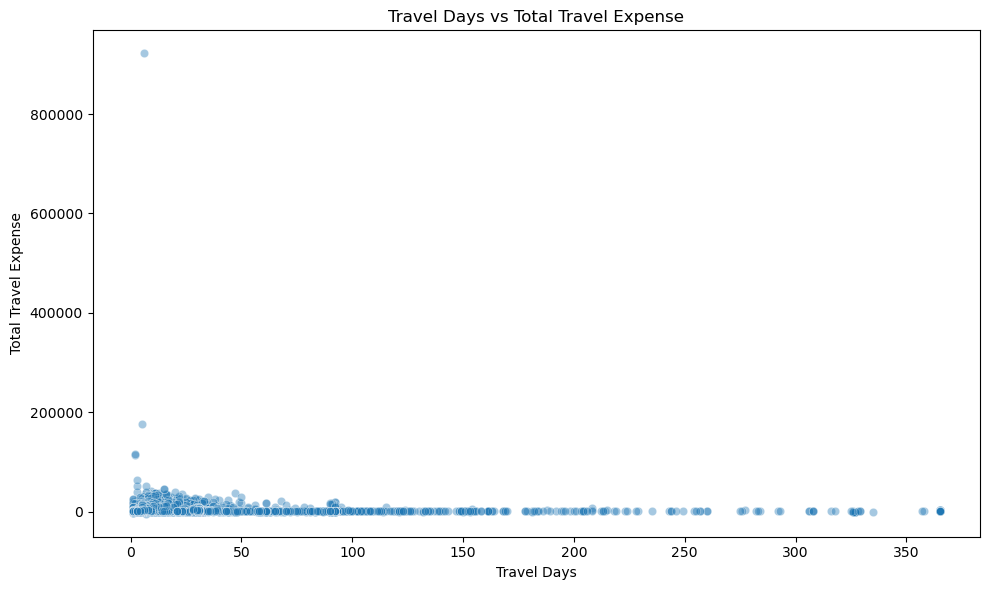

In [42]:
# Scatter plot: Travel Days vs Total Expense

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=correlation_data,
    x='Travel_Days',
    y='total',
    alpha=0.4
)

plt.title('Travel Days vs Total Travel Expense')
plt.xlabel('Travel Days')
plt.ylabel('Total Travel Expense')

plt.tight_layout()
plt.show()

### 9.2 Expense Correlation Heatmap

This analysis examines the correlation between different expense components and total travel expense using a correlation matrix.

In [43]:
# Select expense columns for correlation analysis

correlation_columns = [
    'airfare',
    'other_transport',
    'lodging',
    'meals',
    'other_expenses',
    'total'
]

correlation_matrix = cleaned_df[
    correlation_columns
].corr()

correlation_matrix.round(2)

,airfare,other_transport,lodging,meals,other_expenses,total
airfare,1.00,0.12,0.05,0.12,0.08,0.97
other_transport,0.12,1.00,0.02,0.05,0.04,0.22
lodging,0.05,0.02,1.00,0.01,0.11,0.06
meals,0.12,0.05,0.01,1.00,0.01,0.14
other_expenses,0.08,0.04,0.11,0.01,1.00,0.12
total,0.97,0.22,0.06,0.14,0.12,1.00


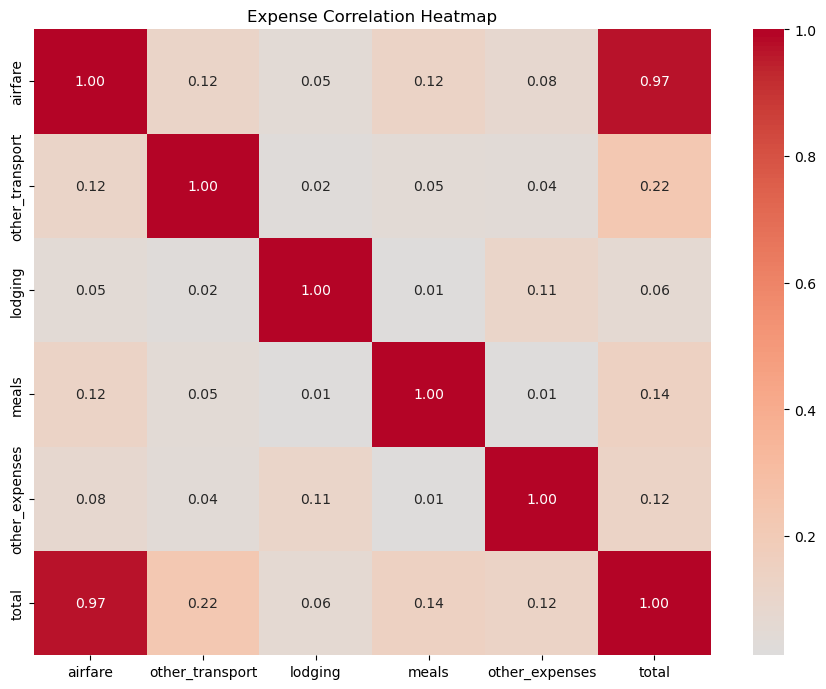

In [44]:
# Visualize the correlation matrix

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Expense Correlation Heatmap')

plt.tight_layout()
plt.show()

## 10. Budget Optimization

This section develops scenario-based budget recommendations using validated travel expense records. Optimization scenarios of 5%, 10%, and 15% are evaluated to estimate potential savings and recommended budgets.

### 10.1 Validated Spend

Only records with a valid reported total and calculated total within an acceptable difference are included in the budget optimization analysis.

In [45]:
# Select valid records for budget optimization

valid_budget_data = cleaned_df[
    (cleaned_df['total'].notna()) &
    (cleaned_df['Calculated_Total'].notna()) &
    (cleaned_df['total'] > 0) &
    ((cleaned_df['total'] - cleaned_df['Calculated_Total']).abs() <= 0.01)
].copy()

actual_spend = valid_budget_data['total'].sum()

print("Valid Records Used:", len(valid_budget_data))
print("Actual Validated Spend:", round(actual_spend, 2))

Valid Records Used: 148932
Actual Validated Spend: 320690014.02


### 10.2 Optimization Scenarios

Three optimization scenarios are evaluated by applying 5%, 10%, and 15% savings targets to the validated travel expenditure.

In [46]:
# Calculate budget optimization scenarios

scenarios = [0.05, 0.10, 0.15]

scenario_data = []

for target in scenarios:
    savings = actual_spend * target
    recommended = actual_spend - savings

    scenario_data.append({
        'Scenario': f'{int(target * 100)}% Optimization',
        'Optimization Target (%)': target * 100,
        'Actual Spend': round(actual_spend, 2),
        'Potential Savings': round(savings, 2),
        'Recommended Budget': round(recommended, 2)
    })

scenario_df = pd.DataFrame(scenario_data)

scenario_df

,Scenario,Optimization Target (%),Actual Spend,Potential Savings,Recommended Budget
0,5% Optimization,5.0,3.206900e+08,16034500.7,3.046555e+08
1,10% Optimization,10.0,3.206900e+08,32069001.4,2.886210e+08
2,15% Optimization,15.0,3.206900e+08,48103502.1,2.725865e+08


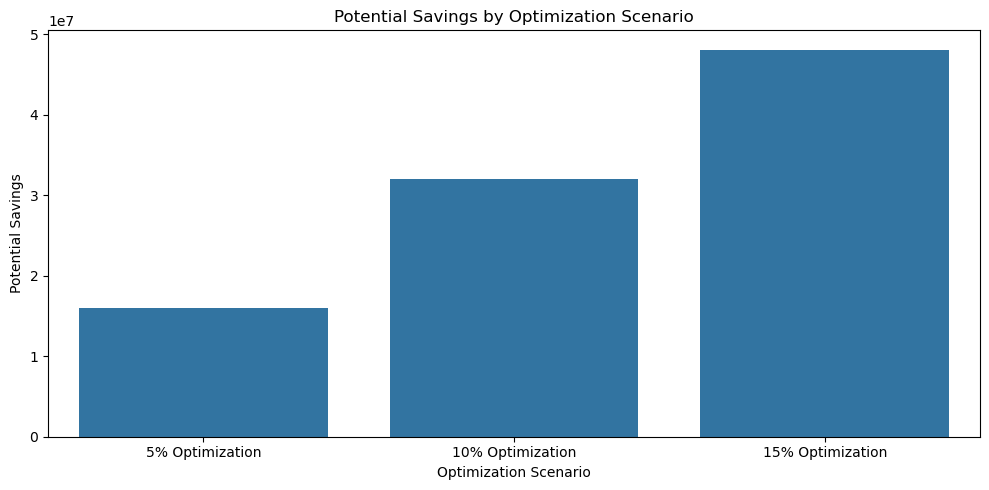

In [47]:
# Visualize potential savings under different scenarios

plt.figure(figsize=(10, 5))

sns.barplot(
    data=scenario_df,
    x='Scenario',
    y='Potential Savings'
)

plt.title('Potential Savings by Optimization Scenario')
plt.xlabel('Optimization Scenario')
plt.ylabel('Potential Savings')

plt.tight_layout()
plt.show()

### 10.3 Category-wise Budget Optimization

This analysis estimates potential savings and recommended budgets for each major travel expense category using a 10% optimization target.

In [48]:
# Calculate category-wise actual spending

category_budget = pd.DataFrame({
    'Expense_Category': [
        'Airfare',
        'Other Transport',
        'Lodging',
        'Meals',
        'Other Expenses'
    ],
    'Actual_Spend': [
        valid_budget_data['airfare'].sum(),
        valid_budget_data['other_transport'].sum(),
        valid_budget_data['lodging'].sum(),
        valid_budget_data['meals'].sum(),
        valid_budget_data['other_expenses'].sum()
    ]
})

category_budget['Optimization_Target'] = 10

category_budget['Potential_Savings'] = (
    category_budget['Actual_Spend']
    * category_budget['Optimization_Target'] / 100
)

category_budget['Recommended_Budget'] = (
    category_budget['Actual_Spend']
    - category_budget['Potential_Savings']
)

category_budget.round(2)

,Expense_Category,Actual_Spend,Optimization_Target,Potential_Savings,Recommended_Budget
0,Airfare,1.938423e+08,10,19384226.99,1.744580e+08
1,Other Transport,2.213514e+07,10,2213514.16,1.992163e+07
2,Lodging,6.753013e+07,10,6753012.60,6.077711e+07
3,Meals,3.390874e+07,10,3390873.87,3.051786e+07
4,Other Expenses,3.273738e+06,10,327373.80,2.946364e+06


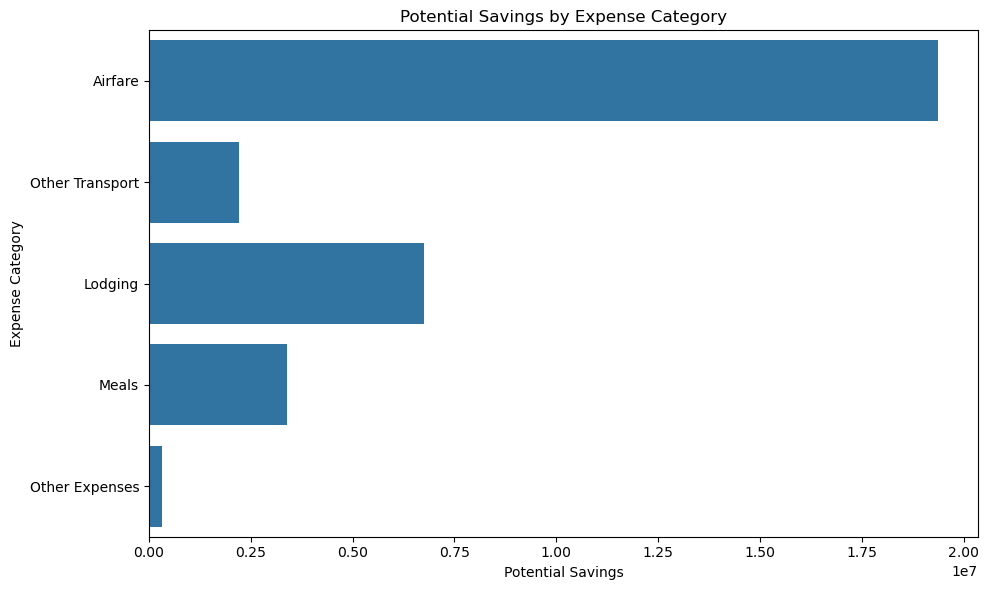

In [49]:
# Visualize potential savings by expense category

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_budget,
    x='Potential_Savings',
    y='Expense_Category'
)

plt.title('Potential Savings by Expense Category')
plt.xlabel('Potential Savings')
plt.ylabel('Expense Category')

plt.tight_layout()
plt.show()

### 10.4 Department-wise Budget Optimization

This analysis estimates potential savings for departments with the highest validated travel spending using a 10% optimization target.

In [50]:
# Calculate department-wise actual spending

department_budget = (
    valid_budget_data[
        valid_budget_data['owner_org'].notna()
    ]
    .groupby('owner_org', as_index=False)['total']
    .sum()
    .rename(columns={'total': 'Actual_Spend'})
    .sort_values('Actual_Spend', ascending=False)
)

# Select top 10 departments
department_budget = department_budget.head(10).copy()

# Apply 10% optimization target
department_budget['Optimization_Target'] = 10

department_budget['Potential_Savings'] = (
    department_budget['Actual_Spend']
    * department_budget['Optimization_Target'] / 100
)

department_budget['Recommended_Budget'] = (
    department_budget['Actual_Spend']
    - department_budget['Potential_Savings']
)

department_budget.round(2)

,owner_org,Actual_Spend,Optimization_Target,Potential_Savings,Recommended_Budget
41,dfatd-maecd,63848705.37,10,6384870.54,57463834.83
50,esdc-edsc,23419894.48,10,2341989.45,21077905.03
44,dnd-mdn,19802121.79,10,1980212.18,17821909.61
56,fin,18103438.43,10,1810343.84,16293094.59
65,ic,12545751.87,10,1254575.19,11291176.68
105,pco-bcp,10271919.28,10,1027191.93,9244727.35
85,nrcan-rncan,8618916.91,10,861891.69,7757025.22
33,cra-arc,7268805.81,10,726880.58,6541925.23
104,pch,6756964.73,10,675696.47,6081268.26
131,tc,6676283.63,10,667628.36,6008655.27


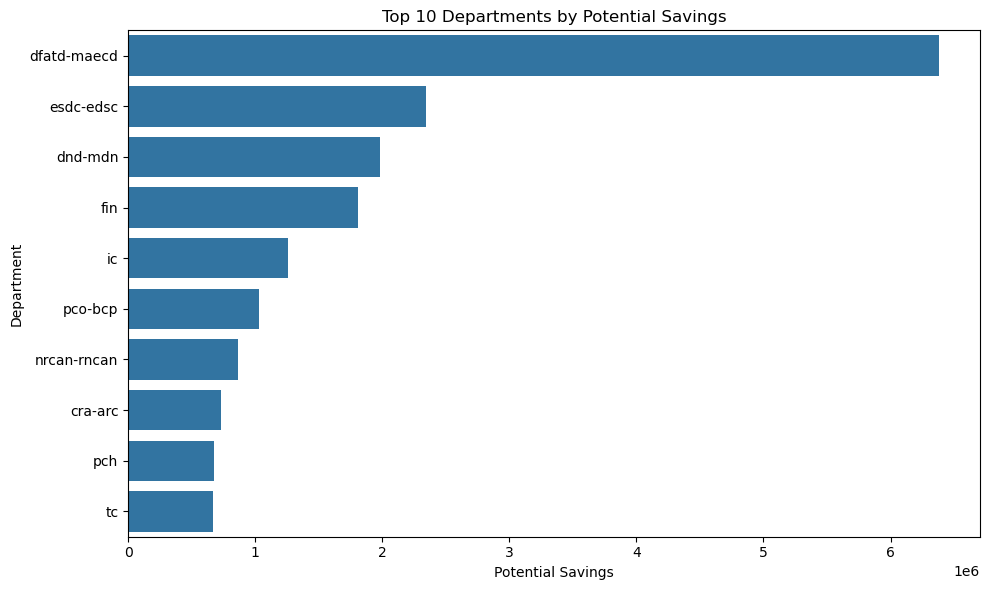

In [51]:
# Visualize potential savings by department

plt.figure(figsize=(10, 6))

sns.barplot(
    data=department_budget,
    x='Potential_Savings',
    y='owner_org'
)

plt.title('Top 10 Departments by Potential Savings')
plt.xlabel('Potential Savings')
plt.ylabel('Department')

plt.tight_layout()
plt.show()

## 11. Key Insights

The analysis of travel expense data revealed several important spending patterns, data quality observations, and budget optimization opportunities.

In [53]:
# Key insights from the analysis

print("KEY INSIGHTS")
print("-" * 60)

print(
    f"1. The dataset contains {len(cleaned_df):,} travel expense records."
)

print(
    f"2. The average reported travel expense is "
    f"{cleaned_df['total'].mean():,.2f}."
)

print(
    f"3. The highest reported travel expense is "
    f"{cleaned_df['total'].max():,.2f}."
)

top_category = category_expense.iloc[0]

print(
    f"4. {top_category['Expense_Category']} is the largest "
    f"expense category, contributing approximately "
    f"{top_category['Percentage']:.2f}% of category spending."
)

print(
    f"5. The validated records used for budget optimization are "
    f"{len(valid_budget_data):,}."
)

print(
    f"6. A 10% optimization scenario indicates potential savings "
    f"of {actual_spend * 0.10:,.2f}."
)

print(
    f"7. The correlation between travel days and total expense is "
    f"{correlation_value:.2f}, indicating a weak linear relationship."
)

print(
    f"8. IQR analysis identified {len(outliers):,} records "
    f"as statistical outliers."
)

KEY INSIGHTS
------------------------------------------------------------
1. The dataset contains 152,900 travel expense records.
2. The average reported travel expense is 2,147.22.
3. The highest reported travel expense is 922,199.00.
4. Airfare is the largest expense category, contributing approximately 59.62% of category spending.
5. The validated records used for budget optimization are 148,932.
6. A 10% optimization scenario indicates potential savings of 32,069,001.40.
7. The correlation between travel days and total expense is 0.07, indicating a weak linear relationship.
8. IQR analysis identified 13,491 records as statistical outliers.


## 12. Conclusion

The Travel Expense Analytics & Budget Optimization project provided a comprehensive analysis of government travel expense data.

Python and Pandas were used for data cleaning, data quality assessment, exploratory data analysis, outlier detection, and correlation analysis. The analysis examined spending trends across years, departments, destinations, and expense categories.

The budget optimization analysis used validated expense records and evaluated 5%, 10%, and 15% optimization scenarios. These scenarios provided estimates of potential savings and recommended budgets to support expense planning.

Overall, the project demonstrates how data analytics can be used to identify spending patterns, detect data quality issues, and support data-driven budget planning and cost optimization.